## Project Responsible AI Part 1
#### Topic: Applying Differential Privacy on Input Data and Model.

By:
* Hamza Khalid 24PGAI0079
* Soham Sanyal 24PGAI0055
* Kishnu Shrivastava 24PGAI0042

Note: this notebook has been coded using code references from:
* https://github.com/srayagarwal/JIO_RAI/
* ChatGPT


We have to first encode the categorical data:

In [7]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load your dataset
df_normal = pd.read_csv('ibm_hr_data.csv')

# Initialize LabelEncoder
label_encoders = {}

# Encode categorical columns
for col in df_normal.columns:
    if df_normal[col].dtype == 'object':
        label_encoders[col] = LabelEncoder()
        df_normal[col] = label_encoders[col].fit_transform(df_normal[col])

# Save the encoded dataset to a new CSV file
df_normal.to_csv('ibm_hr_data_encoded.csv', index=False)
df_normal.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


Finding the important features for building the model:

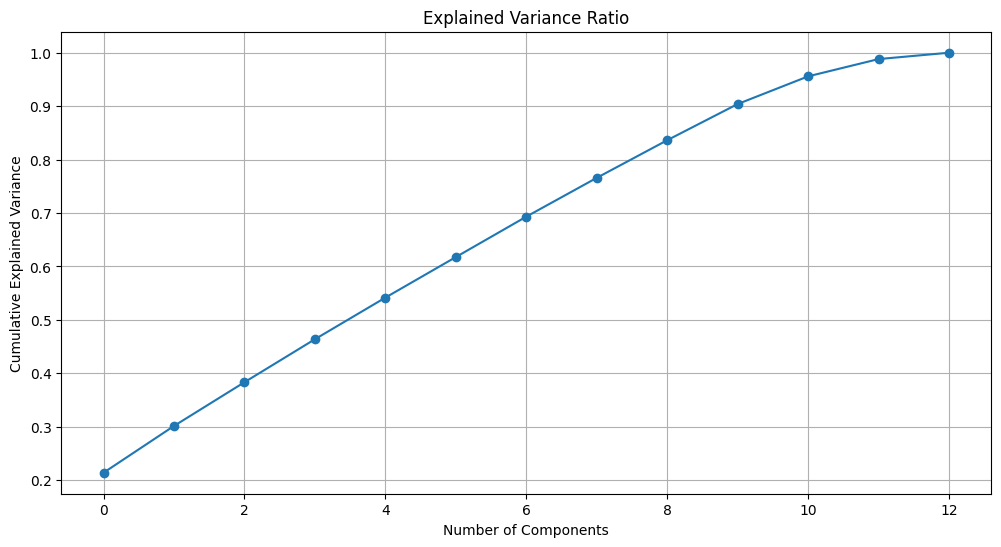

Component 1: TotalWorkingYears
Component 2: MaritalStatus
Component 3: DistanceFromHome
Component 4: DailyRate
Component 5: PercentSalaryHike
Component 6: MonthlyRate
Component 7: EducationField
Component 8: JobRole
Component 9: Gender
Component 10: MaritalStatus
Component 11: Age
Component 12: MonthlyIncome
Component 13: TotalWorkingYears


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

df_encoded = pd.read_csv('ibm_hr_data_encoded.csv')

# Assuming 'data' is your DataFrame with the selected_features
selected_features = ['MonthlyRate', 'DailyRate', 'MonthlyIncome', 'HourlyRate', 'PercentSalaryHike',
                     'DistanceFromHome', 'Age', 'TotalWorkingYears', 'YearsAtCompany', 'JobRole',
                     'Gender', 'MaritalStatus', 'EducationField']

# Selecting the features from the dataset
X = df_encoded[selected_features]

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plotting the explained variance ratio
plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio')
plt.grid(True)
plt.show()

# Get the most important features for each component
num_top_features = 1  # Number of top features to show for each component
top_features = []
for component in pca.components_:
    top_feature_indices = np.argsort(np.abs(component))[-num_top_features:]
    top_features.append([selected_features[i] for i in top_feature_indices])

# Print the top features for each component
for i, features in enumerate(top_features):
    print(f"Component {i+1}: {', '.join(features)}")


In [9]:
# a function to nicely evaluate all the metrics:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from sklearn import metrics



def evaluate(model, X_test, y_test, *args):
    
    if args:
        for arg in args:
            print("#### value of epsilon : {arg} ####".format(arg=arg))
            y_pred = model.predict(X_test)
            
            # Classification Report
            print("Classification Report:")
            print(classification_report(y_test, y_pred))
            
            # AUC
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_pred_proba)
            print(f"AUC: {auc:.4f}")

            # Confusion matrix
            print("\nConfusion Matrix:")
            confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
            cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[False, True])
            cm_display.plot()
            plt.show()

            # F1 Score
            f1 = f1_score(y_test, y_pred)
            print(f"F1 Score: {f1:.4f}")

            # True Positive Rate (Recall)
            recall = recall_score(y_test, y_pred)
            print(f"True Positive Rate (Recall): {recall:.4f}")

            # True Negative Rate
            tnr = confusion_matrix[0, 0] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
            print(f"True Negative Rate (TNR): {tnr:.4f}")

            # False Positive Rate
            fpr = confusion_matrix[0, 1] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
            print(f"False Positive Rate (FPR): {fpr:.4f}")

            epsilon = arg
            accuracy = accuracy_score(y_test, y_pred)
            return epsilon, accuracy
        
    else:
        
        y_pred = model.predict(X_test)
        
        # Classification Report
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        
        # AUC
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"AUC: {auc:.4f}")

        # Confusion matrix
        print("\nConfusion Matrix:")
        confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
        cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[False, True])
        cm_display.plot()
        plt.show()

        # F1 Score
        f1 = f1_score(y_test, y_pred)
        print(f"F1 Score: {f1:.4f}")

        # True Positive Rate (Recall)
        recall = recall_score(y_test, y_pred)
        print(f"True Positive Rate (Recall): {recall:.4f}")

        # True Negative Rate
        tnr = confusion_matrix[0, 0] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
        print(f"True Negative Rate (TNR): {tnr:.4f}")

        # False Positive Rate
        fpr = confusion_matrix[0, 1] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
        print(f"False Positive Rate (FPR): {fpr:.4f}")

        
        
        
        
    # ROC curve and AUC
    # y_pred_proba = model.predict_proba(X_test)[:, 1]
    # fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    # auc = roc_auc_score(y_test, y_pred_proba)

    # plt.figure(figsize=(8, 6))
    # plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    # plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.title('ROC Curve')
    # plt.legend()
    # plt.show()




The sensitive features added to the prediction of attrition can be:

* Age: the model can be biased against certain age groups. For example, older employees may have more health problems and therefore be more likely to leave.

* Gender: This feature can introduce bias if the model learns gender stereotypes or if certain genders are systematically favored or discriminated against in the prediction of attrition.

* MaritalStatus: Marital status can be sensitive as it reveals personal relationship status, which may impact factors related to attrition such as work-life balance or personal priorities.

* EducationField: The field of education can be sensitive as it may reveal personal interests, career specialization, or access to educational opportunities, which can impact job opportunities and, consequently, attrition.

### Adding differential privacy to the input data's sensitive feature...
* age

In [10]:
import pandas as pd
import numpy as np

def apply_differential_privacy(data, columns, epsilon):
   
    
    for col in columns:
        sensitivity = data[col].max() - data[col].min()  # Sensitivity of the parameter
        scale = sensitivity / epsilon  # Scale of the Laplace distribution
        noise = np.random.laplace(0, scale, len(data))  # Generate Laplace noise
        data[col+'_noisy'] = data[col] + noise  # Add noise to the parameter

        # Ensure that the values remain within a reasonable range
        if data[col].dtype == 'int64':
            data[col] = data[col].clip(lower=data[col].min(), upper=data[col].max())
        elif data[col].dtype == 'float64':
            data[col] = data[col].clip(lower=data[col].min())

    return data

def apply_differential_privacy(data, columns, epsilon):
   
    for col in columns:
        sensitivity = data[col].max() - data[col].min()  # Sensitivity of the parameter
        scale = sensitivity / epsilon  # Scale of the Laplace distribution
        noise = np.random.laplace(0, scale, len(data))  # Generate Laplace noise
        data[col+'_noisy'] = data[col] + noise  # Add noise to the parameter

        # Ensure that the values remain within a reasonable range
        if data[col].dtype == 'int64':
            data[col+'_noisy'] = data[col+'_noisy'].clip(lower=data[col].min(), upper=data[col].max())
        elif data[col].dtype == 'float64':
            data[col+'_noisy'] = data[col+'_noisy'].clip(lower=data[col].min())

    return data


# Example usage
data = pd.read_csv('ibm_hr_data_encoded.csv')
epsilon = 0.9  # Privacy budget
columns_to_apply_privacy = ['MonthlyIncome']  # Specify columns to apply differential privacy to
data_privacy_applied = apply_differential_privacy(data.copy(), columns_to_apply_privacy, epsilon)

# Save the differentially private data to a new CSV file
data_privacy_applied.to_csv('ibm_hr_data_encoded_DP.csv', index=False)


### Code to check what value to epsilon to choose:

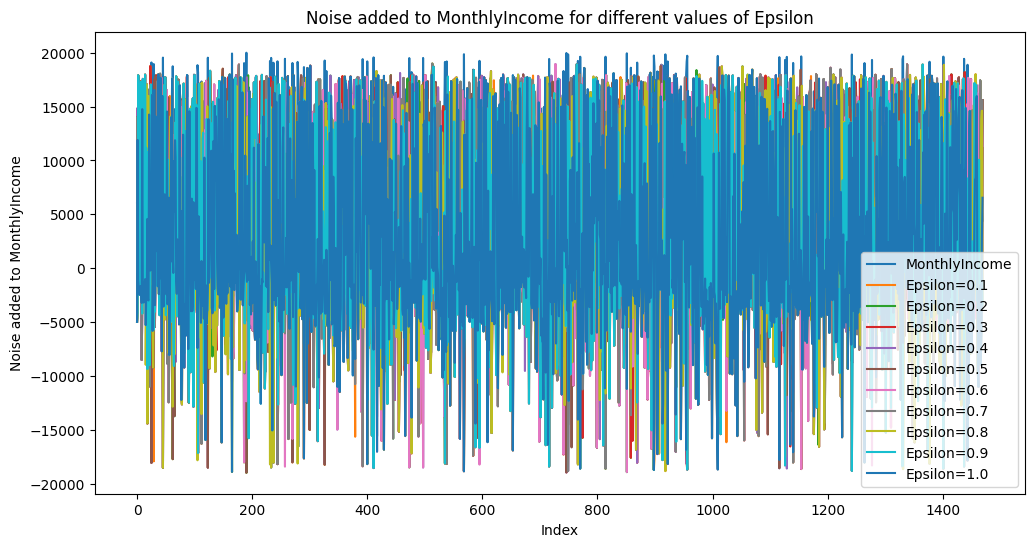

1.0



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Example usage
data = pd.read_csv('ibm_hr_data_encoded.csv')
epsilons = np.linspace(0.1, 1.0, num=10)  # Privacy budgets ranging from 0.1 to 1
columns_to_apply_privacy = ['MonthlyIncome']  # Specify columns to apply differential privacy to

# Apply differential privacy for each epsilon and plot the noise applied to 'Age'
plt.figure(figsize=(12, 6))
plt.plot(data["MonthlyIncome"], label=f'MonthlyIncome')
for epsilon in epsilons:
    data_privacy_applied = apply_differential_privacy(data.copy(), columns_to_apply_privacy, epsilon)
    noise = data_privacy_applied['MonthlyIncome_noisy'] - data_privacy_applied['MonthlyIncome']
    plt.plot(noise, label=f'Epsilon={round(epsilon,2)}')

plt.xlabel('Index')
plt.ylabel('Noise added to MonthlyIncome')
plt.title('Noise added to MonthlyIncome for different values of Epsilon')
plt.legend()
plt.show()

print(epsilon)
print()

### Diffential Privacy in: Model-> Without DP , Input Data-> With DP

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.00      0.00      0.00        58

    accuracy                           0.80       294
   macro avg       0.40      0.50      0.44       294
weighted avg       0.64      0.80      0.71       294

AUC: 0.6589

Confusion Matrix:


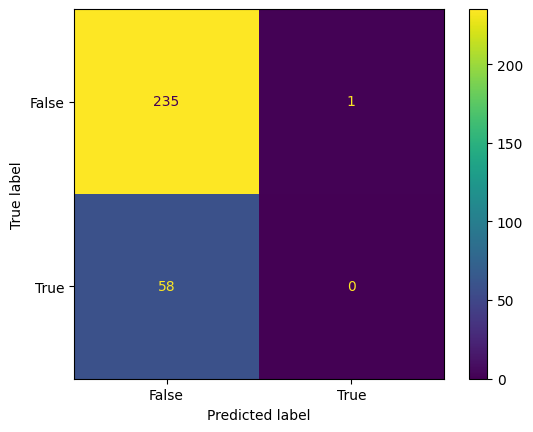

F1 Score: 0.0000
True Positive Rate (Recall): 0.0000
True Negative Rate (TNR): 0.9958
False Positive Rate (FPR): 0.0042


In [13]:
import sklearn
# from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
# Load your dataset
df_encoded_DP = pd.read_csv('ibm_hr_data_encoded_DP.csv')
# Selecting the identified features from the dataset
selected_features = ['TotalWorkingYears', 'MaritalStatus', 'DistanceFromHome', 'DailyRate',
                     'PercentSalaryHike', 'MonthlyRate', 'EducationField', 'JobRole', 'Gender',
                     'Age', 'MonthlyIncome']
X_DP = df_encoded_DP[selected_features]
y_DP = df_encoded_DP['Attrition']  # Assuming 'Attrition' is the target variable



# Splitting the dataset into training and testing sets
X_train_DP, X_test_DP, y_train_DP, y_test_DP = train_test_split(X_DP, y_DP, test_size=0.2, random_state=69)

# Creating and training the random forest classifier
# model_normal_data_DP = RandomForestClassifier(class_weight='balanced')
model_normal_data_DP = LogisticRegression()
model_normal_data_DP.fit(X_train_DP, y_train_DP)


evaluate(model_normal_data_DP, X_test_DP, y_test_DP)
